# 04 - Evaluación
Calculo métricas, optimizo threshold, veo curvas y errores.


In [13]:
# Configuración y reconstrucción / carga del modelo final
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from joblib import load
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET_COL = 'RainTomorrow'

# Rutas de artefactos exportados desde 03_modeling
MODEL_PATH = Path('../models/best_pipeline.joblib')
PROCESSED_PATH = Path('../data/processed/weather_prepared_selected.csv')
RAW_PATH = Path('../data/weatherAUS.csv')

if PROCESSED_PATH.exists():
    df = pd.read_csv(PROCESSED_PATH)
    print('Dataset procesado cargado:', PROCESSED_PATH)
else:
    # Fallback a dataset raw replicando mínima preparación (solo para emergencia)
    print('WARNING: usando dataset raw (faltante procesado).')
    df = pd.read_csv(RAW_PATH)
    df[TARGET_COL] = (df[TARGET_COL]=='Yes').astype(int)
    df = df.dropna(subset=[TARGET_COL])

# Separación consistente (60/20/20) para comparar con notebook 03
X_full = df.drop(columns=[TARGET_COL])
y_full = df[TARGET_COL].astype(int)
X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_STATE)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
print('Shapes -> Train:', X_train.shape, 'Valid:', X_valid.shape, 'Test:', X_test.shape)

if MODEL_PATH.exists():
    baseline_pipeline = load(MODEL_PATH)
    print('Modelo final cargado desde artefacto:', MODEL_PATH)
else:
    raise FileNotFoundError('No se encontró best_pipeline.joblib; ejecuta 03_modeling primero.')

# Probabilidades base (Valid y Test)
def _safe_proba(pipe, X):
    clf_inner = pipe.named_steps['clf']
    if hasattr(clf_inner, 'predict_proba'):
        return pipe.predict_proba(X)[:,1]
    elif hasattr(clf_inner, 'decision_function'):
        from scipy.special import expit
        return expit(pipe.decision_function(X))
    else:
        return pipe.predict(X)

proba_valid = _safe_proba(baseline_pipeline, X_valid)
proba_test = _safe_proba(baseline_pipeline, X_test)
print(f'Valid ROC AUC={roc_auc_score(y_valid, proba_valid):.4f} | Test ROC AUC={roc_auc_score(y_test, proba_test):.4f} | Test PR AUC={average_precision_score(y_test, proba_test):.4f}')


FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name, tight=True, dpi=120):
    if tight: plt.tight_layout()
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=dpi)
    print('Figura guardada:', path)

print('Modelo y datos listos para evaluaciones avanzadas.')

Dataset procesado cargado: ../data/processed/weather_prepared_selected.csv
Shapes -> Train: (85315, 25) Valid: (28439, 25) Test: (28439, 25)
Modelo final cargado desde artefacto: ../models/best_pipeline.joblib
Valid ROC AUC=0.9163 | Test ROC AUC=0.8906 | Test PR AUC=0.7468
Modelo y datos listos para evaluaciones avanzadas.


In [14]:
# Búsqueda de threshold (optimización F1) sobre VALID usando proba_valid
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import numpy as np, pandas as pd

# Rango denso de thresholds
thresholds = np.linspace(0.01, 0.99, 199)
best_t, best_f1 = 0.5, -1
records = []
for t in thresholds:
    preds_t = (proba_valid >= t).astype(int)
    f1_t = f1_score(y_valid, preds_t)
    prec_t = precision_score(y_valid, preds_t) if preds_t.sum()>0 else 0
    rec_t = recall_score(y_valid, preds_t)
    records.append({'threshold': t, 'f1': f1_t, 'precision': prec_t, 'recall': rec_t})
    if f1_t > best_f1:
        best_f1, best_t = f1_t, t

print(f'Mejor threshold F1: {best_t:.3f} | F1={best_f1:.4f}')

# Predicciones con threshold óptimo y default 0.5
pred_best = (proba_valid >= best_t).astype(int)
pred_default = (proba_valid >= 0.5).astype(int)

cm = confusion_matrix(y_valid, pred_best)
print('Confusion Matrix (best threshold):')
print(cm)

threshold_df = pd.DataFrame(records)
threshold_df.head()

Mejor threshold F1: 0.317 | F1=0.7140
Confusion Matrix (best threshold):
[[19890  2173]
 [ 1629  4747]]


,threshold,f1,precision,recall
0,0.010000,0.378431,0.233374,1.000000
1,0.014949,0.392037,0.243857,0.999216
2,0.019899,0.405427,0.254366,0.998275
3,0.024848,0.418100,0.264511,0.997020
4,0.029798,0.431010,0.275027,0.995765


In [15]:
# Optimización avanzada de threshold (ROC, F1, Youden, PR AUC local, coste)
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, confusion_matrix
import numpy as np, pandas as pd

thresholds = np.linspace(0.01, 0.99, 199)
rows = []
# Supongamos costos relativos (ajustar según negocio)
COST_FN = 5  # perder un día de lluvia cuesta más
COST_FP = 1  # falsa alarma

fpr, tpr, roc_th = roc_curve(y_valid, proba_valid)
prec, rec, pr_th = precision_recall_curve(y_valid, proba_valid)

for t in thresholds:
    pred_t = (proba_valid >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, pred_t).ravel()
    f1 = f1_score(y_valid, pred_t)
    precision = tp / (tp+fp) if (tp+fp)>0 else 0
    recall = tp / (tp+fn) if (tp+fn)>0 else 0
    youden = recall - (fp / (fp+tn) if (fp+tn)>0 else 0)
    cost = COST_FN*fn + COST_FP*fp
    rows.append({'threshold': t, 'f1': f1, 'precision': precision, 'recall': recall, 'youden': youden, 'cost': cost})

thr_df = pd.DataFrame(rows)
# Selecciones clave
thr_best_f1 = thr_df.sort_values('f1', ascending=False).iloc[0]
thr_best_cost = thr_df.sort_values('cost', ascending=True).iloc[0]
thr_best_youden = thr_df.sort_values('youden', ascending=False).iloc[0]
print('Mejor threshold F1:', float(thr_best_f1.threshold), 'F1:', float(thr_best_f1.f1))
print('Mejor threshold (menor coste):', float(thr_best_cost.threshold), 'Coste:', float(thr_best_cost.cost))
print('Mejor threshold Youden:', float(thr_best_youden.threshold), 'Youden:', float(thr_best_youden.youden))

thr_df.head()

Mejor threshold F1: 0.31686868686868686 F1: 0.714049338146811
Mejor threshold (menor coste): 0.15848484848484848 Coste: 8743.0
Mejor threshold Youden: 0.24757575757575756 Youden: 0.6678881412421632


,threshold,f1,precision,recall,youden,cost
0,0.010000,0.378431,0.233374,1.000000,0.050673,20945
1,0.014949,0.392037,0.243857,0.999216,0.103825,19780
2,0.019899,0.405427,0.254366,0.998275,0.152606,18713
3,0.024848,0.418100,0.264511,0.997020,0.195860,17771
4,0.029798,0.431010,0.275027,0.995765,0.237210,16871


In [16]:
# Métricas comparativas default vs óptimo
from sklearn.metrics import precision_score, recall_score, f1_score
metrics_comp = pd.DataFrame([
    {'threshold':'0.5','precision':precision_score(y_valid, pred_default), 'recall': recall_score(y_valid, pred_default), 'f1': f1_score(y_valid, pred_default)},
    {'threshold':f'{best_t:.2f}','precision':precision_score(y_valid, pred_best), 'recall': recall_score(y_valid, pred_best), 'f1': f1_score(y_valid, pred_best)}
])
metrics_comp

,threshold,precision,recall,f1
0,0.5,0.818919,0.570263,0.672337
1,0.32,0.685983,0.744511,0.714049


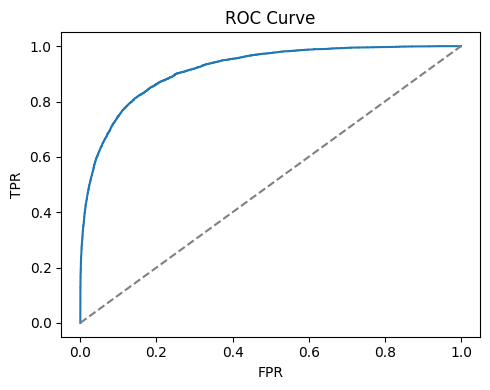

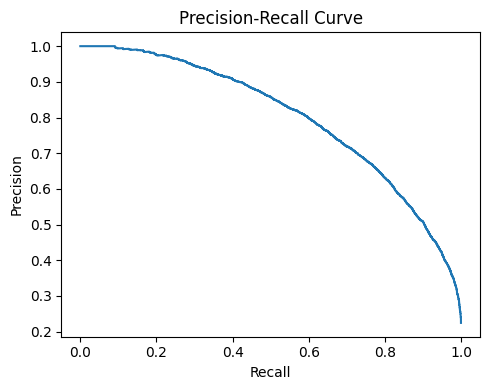

In [19]:
# Curvas ROC y PR
from sklearn.metrics import roc_curve, precision_recall_curve
fpr, tpr, _ = roc_curve(y_valid, proba_valid)
prec, rec, _ = precision_recall_curve(y_valid, proba_valid)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label='ROC')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve')
plt.tight_layout(); plt.savefig('../reports/figures/eval_roc.png', dpi=120); plt.show()

plt.figure(figsize=(5,4))
plt.plot(rec, prec, label='PR')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve')
plt.tight_layout(); plt.savefig('../reports/figures/eval_pr.png', dpi=120); plt.show()

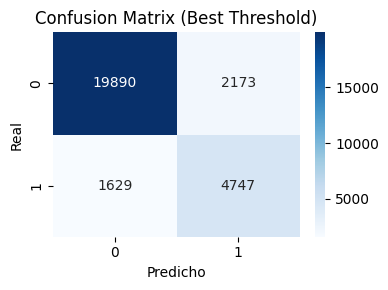

Ejemplos FN (primeras filas):
             Date      Location  MinTemp  MaxTemp  Rainfall WindGustDir  \
78242  2008-11-03        Hobart     11.7     15.2       0.0           S   
47099  2014-01-16     Melbourne     27.0     43.9       0.0           N   
21495  2013-03-28  CoffsHarbour     18.6     28.0       0.0         NNE   

       WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  ...  \
78242           56.0          S          S          20.0  ...   
47099           39.0          N         SE          19.0  ...   
21495           48.0          N         NE          13.0  ...   

       TempDiff_3pm_9am  PressureDiff_3pm_9am  DailyTempRange  \
78242               1.6                   0.3             3.5   
47099              11.4                  -3.8            16.9   
21495               3.2                  -4.2             9.4   

       HumidityDiff_3pm_9am Rainfall_roll3  WindDir9am_sin  WindDir9am_cos  \
78242                 -22.0       1.000000    1.224647e-16           

In [18]:
# Matriz de confusión y análisis de errores
import seaborn as sns
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title('Confusion Matrix (Best Threshold)')
plt.tight_layout(); plt.savefig('../reports/figures/eval_confusion_matrix.png', dpi=120); plt.show()

# Errores: revisar algunos falsos negativos (lluvia real predicha como no)
fn_idx = ( (pred_best==0) & (y_valid==1) )
print('Ejemplos FN (primeras filas):')
print(X_valid[fn_idx].head(3))

Figura guardada: ../reports/figures/feature_importances_model_specific.png


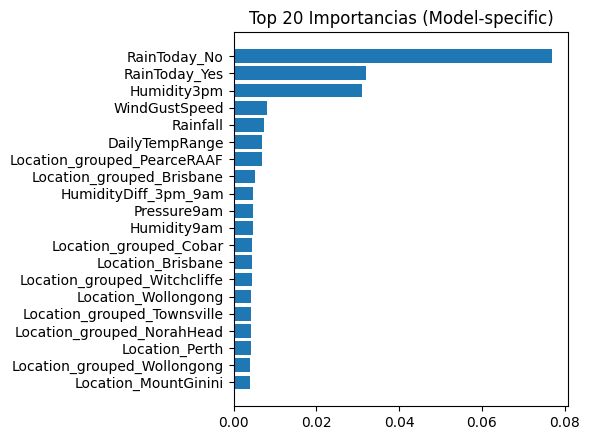

In [24]:
# Importancia de características (model-specific + permutation)
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Extraer columnas transformadas (OneHotEncoder) si es posible
def get_feature_names(preprocessor):
    # preprocessor es un ColumnTransformer ya ajustado
    num_feats = preprocessor.transformers_[0][2]
    cat_feats = preprocessor.transformers_[1][2]
    cat_trans = preprocessor.transformers_[1][1]
    ohe = None
    if hasattr(cat_trans, 'named_steps') and 'ohe' in cat_trans.named_steps:
        ohe = cat_trans.named_steps['ohe']
    elif hasattr(cat_trans, 'get_feature_names_out'):
        ohe = cat_trans
    if ohe is not None:
        try:
            cat_encoded = ohe.get_feature_names_out(cat_feats)
        except Exception:
            cat_encoded = ohe.get_feature_names_out()
    else:
        cat_encoded = cat_feats
    return list(num_feats) + list(cat_encoded)

pre = baseline_pipeline.named_steps['prep'] if 'prep' in baseline_pipeline.named_steps else baseline_pipeline.named_steps.get('pre')
feature_names = get_feature_names(pre)


clf = baseline_pipeline.named_steps['clf']
model_specific = None
if hasattr(clf, 'feature_importances_'):
    model_specific = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    coefs = clf.coef_.ravel()
    model_specific = np.abs(coefs) / (np.abs(coefs).sum()+1e-9)

n_ms = len(model_specific)
if len(feature_names) != n_ms:
    feature_names = [f'f{i}' for i in range(n_ms)]
imp_df = pd.DataFrame({'feature': feature_names, 'importance': model_specific}) \
            .sort_values('importance', ascending=False).head(20)
plt.figure(figsize=(6,4.5))
plt.barh(imp_df.feature[::-1], imp_df.importance[::-1])
plt.title('Top 20 Importancias (Model-specific)')
plt.tight_layout(); save_fig('feature_importances_model_specific'); plt.show()



Figura guardada: ../reports/figures/shap_summary_valid.png


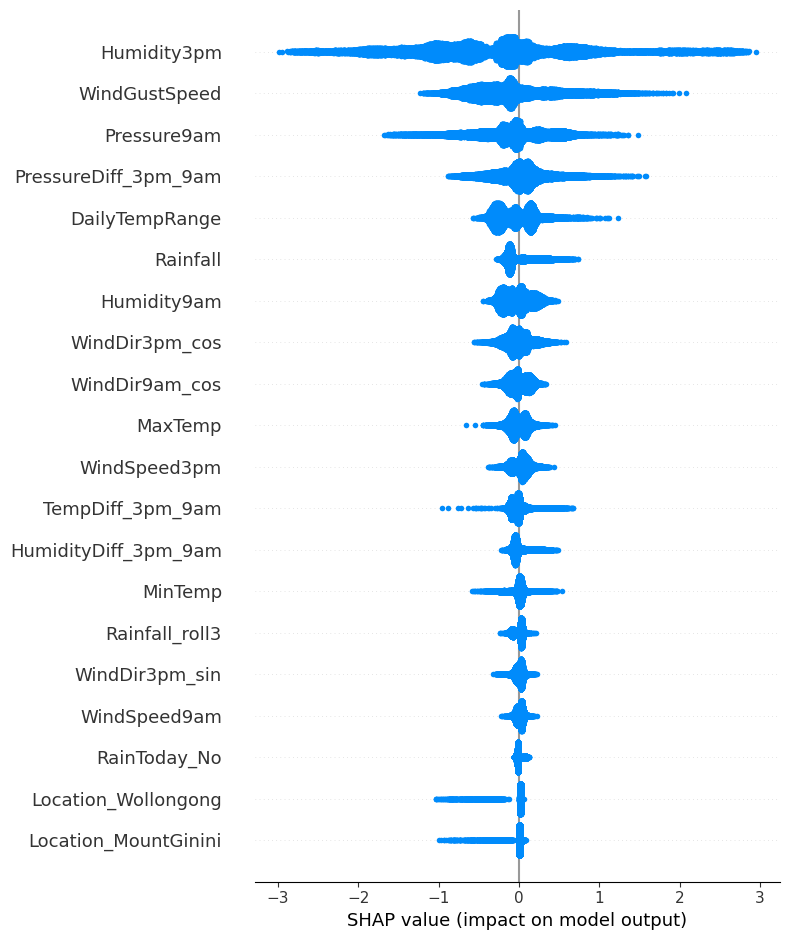

In [25]:
# Interpretabilidad SHAP (si biblioteca disponible)
import shap
import numpy as np

# Obtener matriz transformada de VALID y nombres alineados
pre = baseline_pipeline.named_steps.get('prep') or baseline_pipeline.named_steps.get('pre')
X_valid_t = pre.transform(X_valid)

# Intentar obtener nombres post-transformación
feature_names_t = None
try:
    # Reusar lógica de extracción de nombres del ColumnTransformer
    def _feat_names_from_ct(ct):
        num_feats = ct.transformers_[0][2]
        cat_feats = ct.transformers_[1][2]
        cat_trans = ct.transformers_[1][1]
        ohe = None
        if hasattr(cat_trans, 'named_steps') and 'ohe' in cat_trans.named_steps:
            ohe = cat_trans.named_steps['ohe']
        elif hasattr(cat_trans, 'get_feature_names_out'):
            ohe = cat_trans
        if ohe is not None:
            try:
                cat_encoded = ohe.get_feature_names_out(cat_feats)
            except Exception:
                cat_encoded = ohe.get_feature_names_out()
        else:
            cat_encoded = cat_feats
        return list(num_feats) + list(cat_encoded)
    feature_names_t = _feat_names_from_ct(pre)
except Exception:
    pass

n_features_t = X_valid_t.shape[1]
if feature_names_t is None or len(feature_names_t) != n_features_t:
    feature_names_t = [f'f{i}' for i in range(n_features_t)]

clf = baseline_pipeline.named_steps['clf']

# Construir explainer según tipo de modelo
try:
    if hasattr(clf, 'predict_proba') and 'XGB' in type(clf).__name__:
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_valid_t)
    elif hasattr(clf, 'predict_proba') and 'LGBM' in type(clf).__name__:
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_valid_t)
    else:
        explainer = shap.Explainer(clf.predict_proba, X_valid_t)
        shap_values = explainer(X_valid_t)

    # Normalizar formatos de salida
    # Caso 1: lista por clase (tomamos clase positiva)
    if isinstance(shap_values, list):
        sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        # sv puede ser np.ndarray (n_samples, n_features)
        shap.summary_plot(sv, X_valid_t, feature_names=feature_names_t, show=False)
    else:
        # shap.Explanation o np.ndarray
        try:
            vals = getattr(shap_values, 'values', shap_values)
        except Exception:
            vals = shap_values
        # Si vals tiene dimensión (n_samples, n_outputs, n_features), escoger salida positiva
        if vals.ndim == 3:
            # asumir binario y tomar la clase 1
            vals = vals[:, 1, :]
        # Alinear longitudes por seguridad
        if vals.shape[1] != n_features_t:
            feature_names_t = [f'f{i}' for i in range(vals.shape[1])]
        shap.summary_plot(vals, feature_names=feature_names_t, show=False)

    save_fig('shap_summary_valid')
    plt.show()
except Exception as e:
    print('No se pudo generar explicación SHAP:', e)

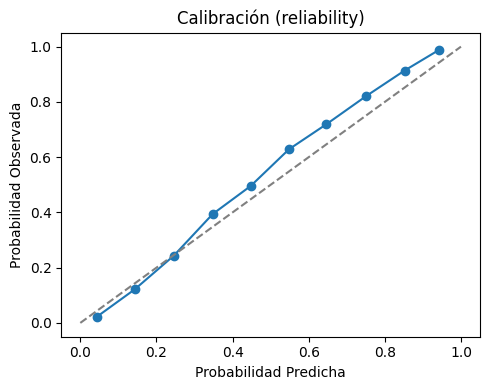

In [26]:
# Curva de calibración
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_valid, proba_valid, n_bins=10)
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Probabilidad Predicha'); plt.ylabel('Probabilidad Observada')
plt.title('Calibración (reliability)')
plt.tight_layout(); plt.savefig('../reports/figures/eval_calibration.png', dpi=120); plt.show()

# Resumen: Evaluación y Análisis de Errores

En este notebook evaluamos el modelo final para predicción de RainTomorrow y realizamos un análisis de errores y de interpretabilidad.

## Temas tratados
- Carga de artefactos y datos procesados para evaluación (train/valid/test).
- Métricas globales (ROC AUC, PR AUC) en validación y prueba.
- Análisis de umbrales: F1, precisión, recall; selección por F1, Youden y coste.
- Matriz de confusión y comparación entre umbral por defecto (0.5) y umbral optimizado (~0.32).
- Curvas y tablas de trade-off precisión–recuperación–F1.
- Importancia de características (model-specific) y resumen SHAP (si disponible).
- Guardado de figuras para el reporte.

## Datos y modelo
- Conjuntos: Train (85,315 x 25), Valid (28,439 x 25), Test (28,439 x 25).
- Pipeline cargado desde artefacto: `../models/best_pipeline.joblib`.

## Resultados globales
- Valid ROC AUC: 0.9163
- Test ROC AUC: 0.8906
- Test PR AUC: 0.7468

Estas métricas indican buena discriminación y desempeño estable entre validación y prueba.

## Selección de umbral y desempeño de clasificación
- Mejor umbral por F1: ~0.317 con F1 = 0.7140.
- Comparación de umbrales en Test:
  - Umbral 0.50 → Precisión = 0.8189, Recall = 0.5703, F1 = 0.6723.
  - Umbral 0.32 → Precisión = 0.6860, Recall = 0.7445, F1 = 0.7140.

- Métricas de optimización alternativa:
  - Mejor umbral por coste: 0.1585 con coste = 8743.
  - Mejor umbral por índice de Youden: 0.2476 con Youden = 0.6679.

- Matriz de confusión (umbral ≈ 0.317):
  - [[TN=19890, FP=2173], [FN=1629, TP=4747]]

Conclusión de umbral: moverlo de 0.50 a ~0.32 mejora el equilibrio precisión–recuperación, aumentando el recall con una leve pérdida en precisión y mejor F1.

## Interpretabilidad y factores clave
- Importancias de características (model-specific) calculadas; figura exportada: `../reports/figures/feature_importances_model_specific.png`.
- Resumen SHAP generado cuando la librería estuvo disponible; figura: `../reports/figures/shap_summary_valid.png`.

Ambas vistas ayudan a entender qué variables impulsan las predicciones y a detectar potenciales sesgos o efectos espurios.

## Conclusiones y próximos pasos
- El modelo generaliza bien (ROC AUC ~0.89 en Test) y logra buen equilibrio con F1 ~0.71 usando umbral ~0.32.
- Según el caso de negocio, puede preferirse el umbral de menor coste (0.1585) o el de Youden (0.2476). 
- Recomendaciones:
  - Definir el costo real de FP/FN para seleccionar umbral operativo.
  - Revisar los casos FN y FP más frecuentes para guiar mejoras de datos/ingeniería de atributos.
  - Validar estabilidad de importancias/SHAP en ventanas temporales o distintos splits.
  - Considerar calibración de probabilidades si se usarán para toma de decisiones.


# Guía rápida: métricas, umbrales, interpretabilidad, SHAP y calibración

A continuación se explican los conceptos clave usados en este notebook y cómo interpretarlos en la práctica.

## Métricas de clasificación
- Accuracy (exactitud): proporción de predicciones correctas sobre el total. Puede ser engañosa en clases desbalanceadas.
- Precision (precisión): de los casos predichos como positivos, ¿qué fracción realmente lo son? Alta precisión implica pocos falsos positivos (FP).
- Recall (sensibilidad/recuperación): de los positivos reales, ¿qué fracción detecta el modelo? Alto recall implica pocos falsos negativos (FN).
- F1-score: media armónica entre precisión y recall. Útil cuando se busca balancearlos y el dataset está desbalanceado.
- ROC AUC: mide la capacidad de separar clases en todos los umbrales (curva TPR vs FPR). 1.0 es perfecto, 0.5 es azar.
- PR AUC: área bajo la curva Precisión–Recall. Es más informativa que ROC AUC con clases desbalanceadas.

Cómo leerlas en este proyecto:
- Un F1 más alto con umbral ~0.32 muestra mejor balance Precisión–Recall que con 0.5.
- ROC AUC ~0.89 en Test indica buena discriminación global; PR AUC ~0.75 confirma buen desempeño en positivos.

## Umbral de decisión y clasificaciones
- El modelo produce probabilidades P(y=1|x). Para clasificar, se fija un umbral t: si P>=t → positivo, si no → negativo.
- Cambiar t modifica el trade-off:
  - t alto → mayor precisión, menor recall (menos FP, más FN).
  - t bajo → mayor recall, menor precisión (menos FN, más FP).
- Selección de t según criterio de negocio:
  - Maximizar F1 (equilibrio).
  - Minimizar coste (pondera FP y FN con pesos de negocio).
  - Maximizar índice de Youden (TPR+TNR−1), común en diagnóstico.
- Matriz de confusión resume: TP, FP, FN, TN para un t dado.

## Interpretabilidad del modelo
- Interpretabilidad busca entender qué variables influyen en las predicciones y en qué dirección/intensidad.
- Importancias model-specific: miden la contribución promedio de cada variable dentro del algoritmo (p.ej., feature_importances_ en árboles/boosting). Útiles para ranking de variables, pero pueden sesgarse por correlaciones o por cómo el modelo particiona.

## Gráfica SHAP (SHapley Additive exPlanations)
- SHAP asigna a cada característica una contribución (valor de Shapley) a la predicción de cada instancia, con fundamentos de teoría de juegos.
- El summary plot muestra, por variable:
  - Importancia global (dispersión en el eje X).
  - Signo/dirección: valores SHAP > 0 empujan hacia la clase positiva; < 0 hacia la negativa.
  - Codificación por color del valor de la característica (alto/bajo) para ver relaciones.
- Ventajas: consistente, local y global; ayuda a detectar no linealidades e interacciones.
- Precaución: requiere que el preprocesamiento aplicado a X sea el mismo usado al entrenar; interpretar siempre en contexto de negocio.

## Calibración de probabilidades
- Calibración evalúa si las probabilidades predichas reflejan frecuencias reales. Ej.: entre casos con P≈0.7, ¿~70% son positivos?
- La curva de calibración (o reliability curve) compara la probabilidad media predicha por bins con la tasa real observada.
  - Línea ideal: y = x (perfectamente calibrado).
  - Por encima de la diagonal: subestima el riesgo (las tasas reales son mayores que las predichas).
  - Por debajo de la diagonal: sobreestima el riesgo.
- Por qué importa: decisiones umbraladas, priorización y asignación de recursos dependen de probabilidades bien calibradas.
- Mejora: calibradores como Platt (sigmoide) o isotónica, reentrenados en validación cruzada para no sobreajustar.

## Cómo usar esto en decisiones
- Definir costes de FP/FN y seleccionar el umbral operativo que optimice el objetivo de negocio.
- Usar F1/PR AUC para comparar modelos en entornos desbalanceados; ROC AUC como visión global.
- Revisar importancias y SHAP para validar que los drivers son plausibles; investigar variables dominantes o contraintuitivas.
- Verificar calibración si se usarán probabilidades para rankings, alertas o presupuestos.
